# Bible Mapping Visualisation — New Testament
Explores `leftover_greek`, `leftover_latvian` and overall mapping coverage across books and chapters.
Structure: Greek (main) → Latvian (mapped), single-layer.

## configuration

In [12]:
prefix_outputs="0_leftovers_out/0_LO_NT_"

## all graphs

In [13]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import warnings
warnings.filterwarnings('ignore')

BIBLE_DIR = Path('../bible')  # adjust if needed
print(f"Bible dir exists: {BIBLE_DIR.exists()}")

Bible dir exists: True


In [38]:
# ── Load all chapters (NT: Greek → Latvian, single layer) ─────────────────────
records = []

for book_dir in sorted(BIBLE_DIR.iterdir()):
    if not book_dir.is_dir():
        continue
    book = book_dir.name
    for json_file in sorted(
        [f for f in book_dir.glob('*.json') if f.stem.isdigit()],
        key=lambda x: int(x.stem)
    ):
        chapter = int(json_file.stem)
        try:
            verses = json.loads(json_file.read_text(encoding='utf-8'))
        except Exception as e:
            print(f"  skip {json_file}: {e}")
            continue

        total_words = 0
        #flag, how many ORIG lang words have at least 1 Latvian word mapped
        total_latvian_mapped = 0
        leftover_latvian_words = 0
        total_words_latvian = 0

        for verse in verses:
            for gw in verse.get('greek_words', []):
                total_words += 1
                if gw.get('latvian'):  # non-empty list means mapped
                    total_latvian_mapped += 1
                    total_words_latvian += len(gw.get('latvian'))
            leftover_latvian_words += len(verse.get('leftover_latvian', []))
            total_words_latvian += len(verse.get('leftover_latvian', []))

        records.append({
            'book': book,
            'chapter': chapter,
            'total_words': total_words,
            'has_latvian_mapped': total_latvian_mapped,
            'total_words_latvian': total_words_latvian,
            'leftover_latvian': leftover_latvian_words,
        })

df = pd.DataFrame(records)
df['has_a_latvian_pct'] = df['has_latvian_mapped'] / df['total_words'].replace(0, pd.NA) * 100
df['latvian_maped_pct'] = ((df['total_words_latvian'].replace(0, pd.NA)) - (df['leftover_latvian'].replace(0, pd.NA))) / \
                (df['total_words_latvian'].replace(0, pd.NA)) * 100
df['has_leftover_latvian'] = df['leftover_latvian'] > 0

print(f"Loaded {len(df)} chapters across {df['book'].nunique()} books")
df.head()

Loaded 260 chapters across 27 books


,book,chapter,total_words,has_latvian_mapped,total_words_latvian,leftover_latvian,has_a_latvian_pct,latvian_maped_pct,has_leftover_latvian
0,1_corinthians,1,500,386,509,60,77.200000,88.212181,True
1,1_corinthians,2,288,223,289,28,77.430556,90.311419,True
2,1_corinthians,3,340,288,376,24,84.705882,93.617021,True
3,1_corinthians,4,346,278,387,31,80.346821,91.989664,True
4,1_corinthians,5,221,168,244,40,76.018100,83.606557,True


## 1. Overall mapping coverage — Pie chart

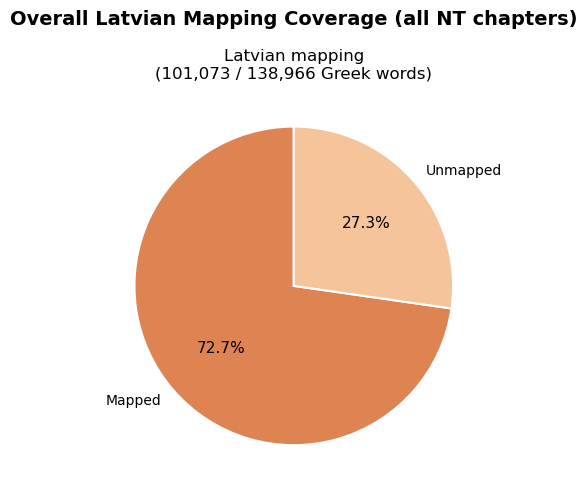

In [40]:
total_words    = df['total_words'].sum()
latvian_mapped = df['has_latvian_mapped'].sum()
latvian_unmapped = total_words - latvian_mapped

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Overall Latvian Mapping Coverage (all NT chapters)', fontsize=14, fontweight='bold')

wedges, texts, autotexts = ax.pie(
    [latvian_mapped, latvian_unmapped],
    labels=['Mapped', 'Unmapped'],
    colors=['#DD8452', '#F5C49A'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts: at.set_fontsize(11)
ax.set_title(f'Latvian mapping\n({latvian_mapped:,} / {total_words:,} Greek words)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{prefix_outputs}overall_coverage_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.A Latvian usage

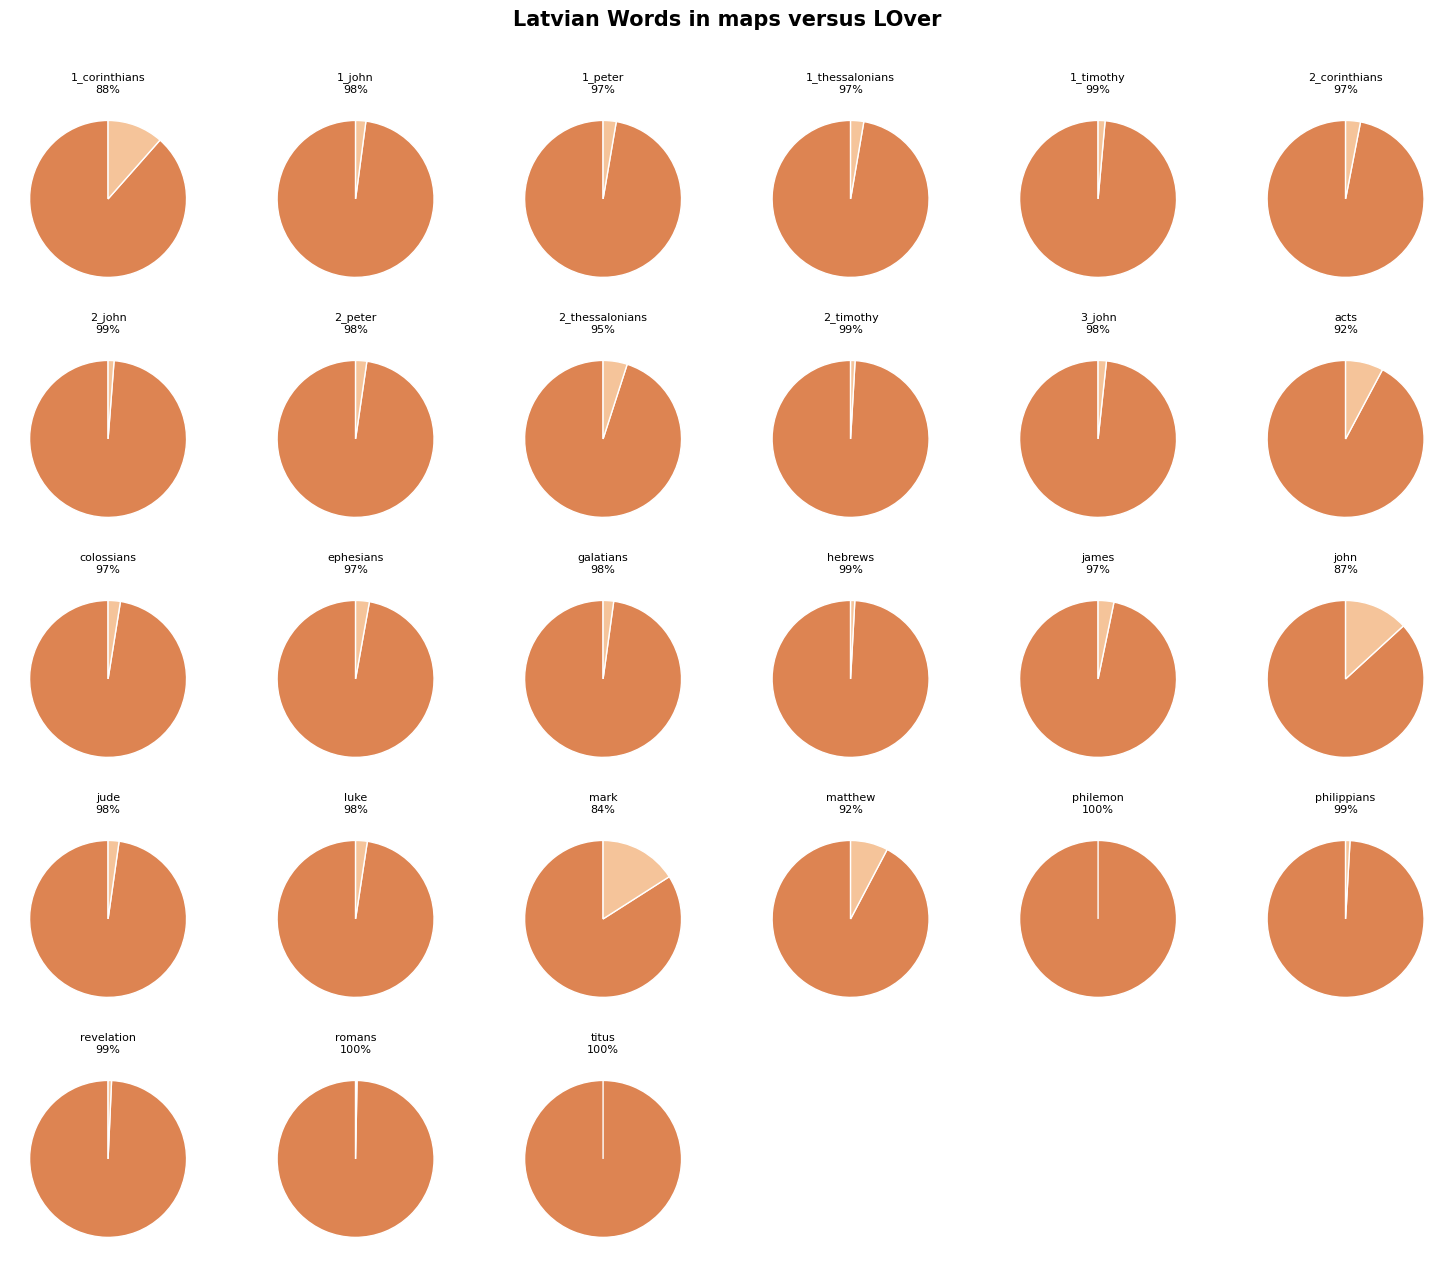

In [48]:
book_df = df.groupby('book').agg(
    total_words=('total_words', 'sum'),
    latvian_mapped=('has_latvian_mapped', 'sum'),
    leftover_latvian=('leftover_latvian', 'sum'),
    total_words_latvian=('total_words_latvian', 'sum'),
    chapters=('chapter', 'count'),
).reset_index()

book_df['latvian_maped_pct'] = (book_df['total_words_latvian'] - book_df['leftover_latvian']) / \
                (book_df['total_words_latvian']) * 100
#.fillna(0)
#print(book_df[:-7])
books = book_df['book'].tolist()
n = len(books)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
fig.suptitle('Latvian Words in maps versus LOver', fontsize=15, fontweight='bold', y=1.01)
axes_flat = axes.flatten() if nrows > 1 else [axes] if n == 1 else axes.flatten()

for i, (_, row) in enumerate(book_df.iterrows()):
    ax = axes_flat[i]
    pct = row['latvian_maped_pct']
    ax.pie(
        [pct, 100 - pct],
        colors=['#DD8452', '#F5C49A'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )
    ax.set_title(f"{row['book']}\n{pct:.0f}%", fontsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.savefig(f'{prefix_outputs}per_book_latvian_USE_vs_LO_pies.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Per-book mapping coverage — Pie charts

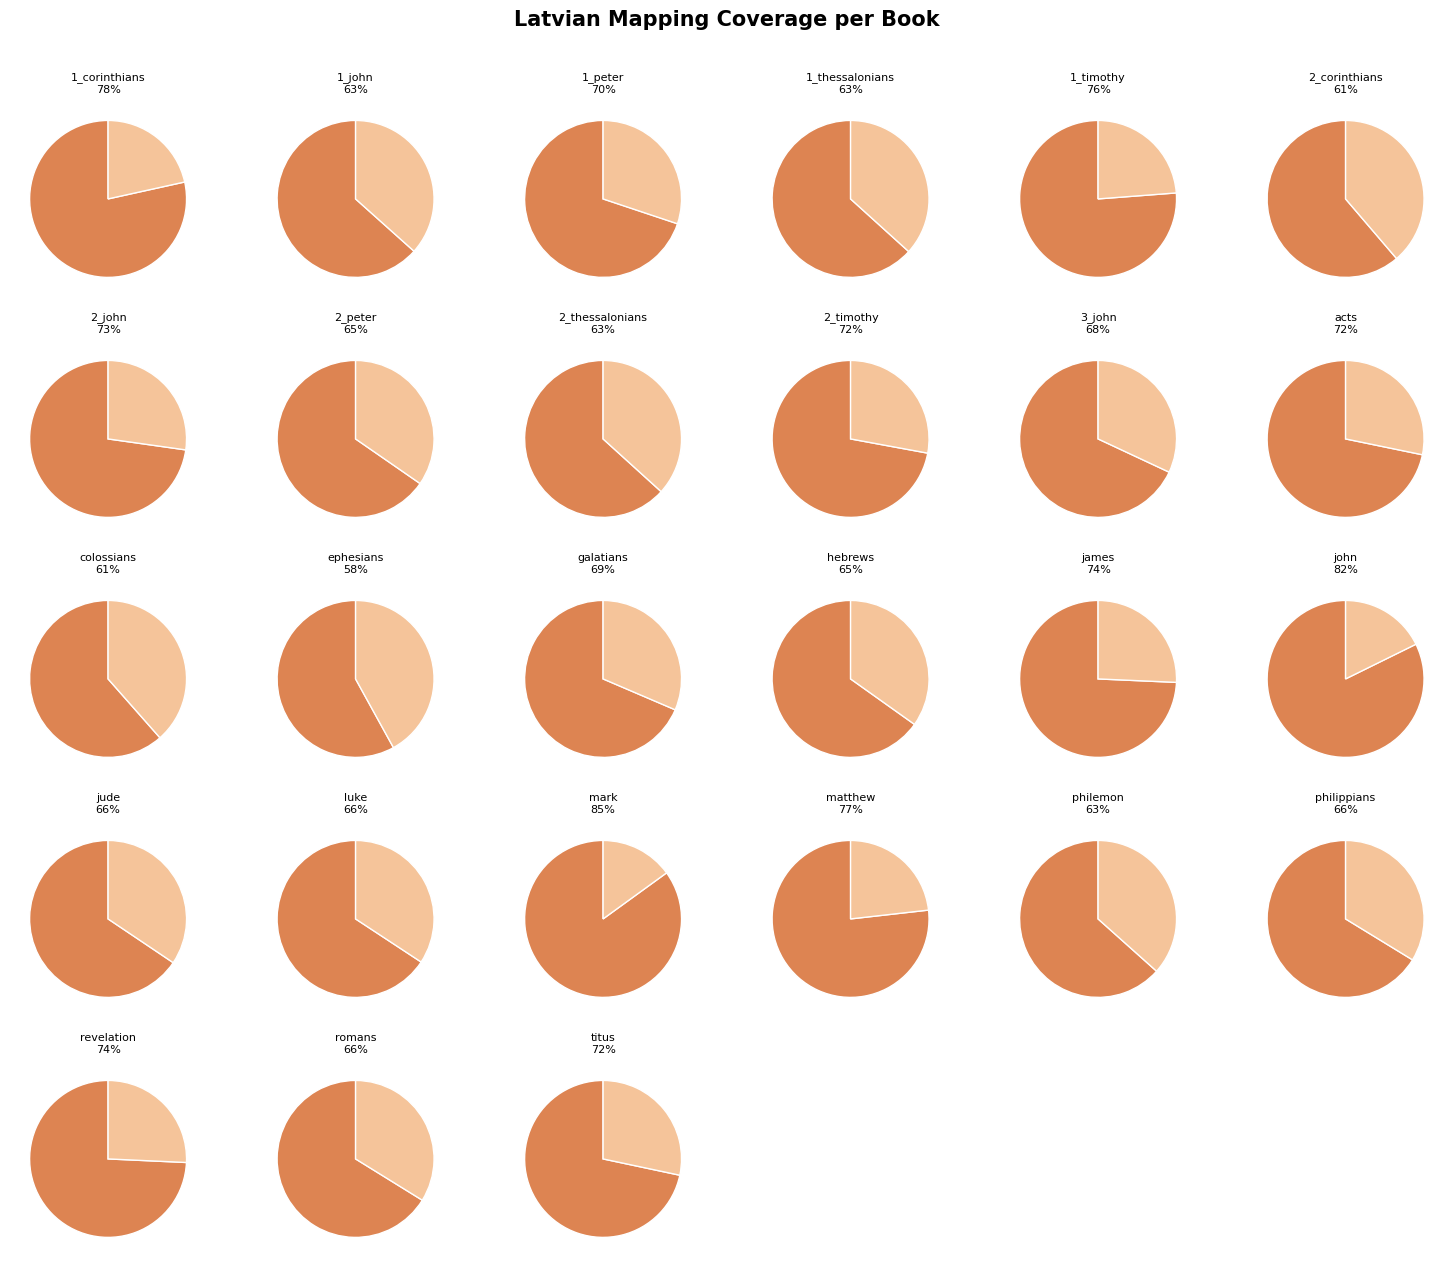

In [41]:
book_df = df.groupby('book').agg(
    total_words=('total_words', 'sum'),
    latvian_mapped=('has_latvian_mapped', 'sum'),
    leftover_latvian=('leftover_latvian', 'sum'),
    total_words_latvian=('total_words_latvian', 'sum'),
    chapters=('chapter', 'count'),
).reset_index()
book_df['latvian_pct'] = book_df['latvian_mapped'] / book_df['total_words'] * 100
book_df['latvian_maped_pct'] = book_df['latvian_mapped'] / (book_df['total_words_latvian'].replace(0, pd.NA)) * 100

books = book_df['book'].tolist()
n = len(books)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
fig.suptitle('Latvian Mapping Coverage per Book', fontsize=15, fontweight='bold', y=1.01)
axes_flat = axes.flatten() if nrows > 1 else [axes] if n == 1 else axes.flatten()

for i, (_, row) in enumerate(book_df.iterrows()):
    ax = axes_flat[i]
    pct = row['latvian_pct']
    ax.pie(
        [pct, 100 - pct],
        colors=['#DD8452', '#F5C49A'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )
    ax.set_title(f"{row['book']}\n{pct:.0f}%", fontsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.savefig(f'{prefix_outputs}per_book_latvian_pies.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Leftover Latvian words — top chapters

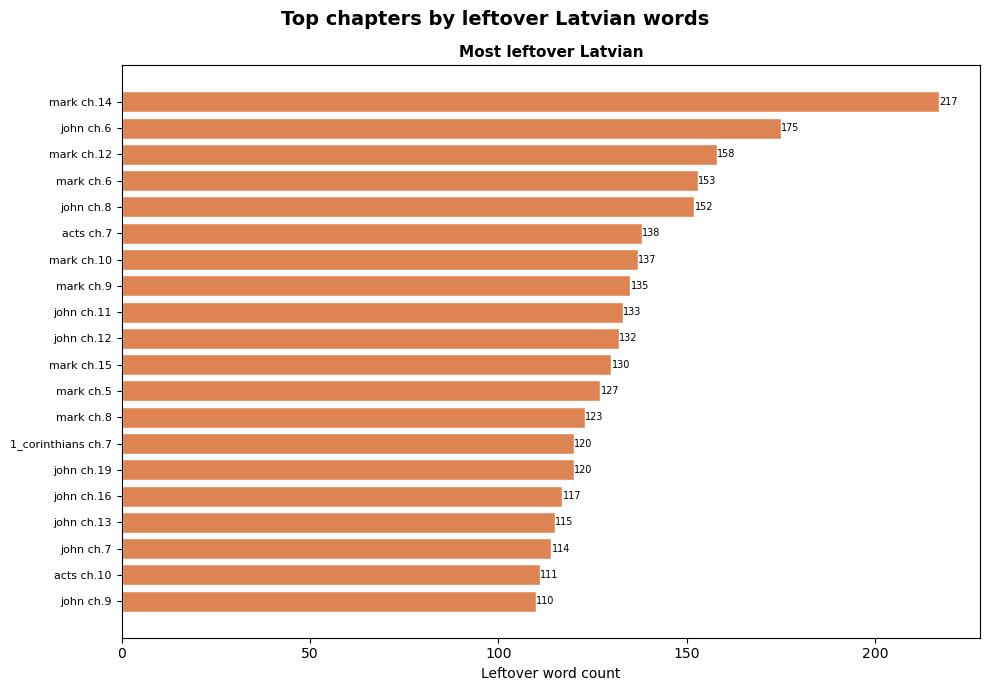

In [17]:
top_latvian = df.nlargest(20, 'leftover_latvian')[['book','chapter','leftover_latvian']]

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Top chapters by leftover Latvian words', fontsize=14, fontweight='bold')

labels = top_latvian['book'] + ' ch.' + top_latvian['chapter'].astype(str)
ax.barh(labels.values[::-1], top_latvian['leftover_latvian'].values[::-1],
        color='#DD8452', edgecolor='white')
ax.set_title('Most leftover Latvian', fontsize=11, fontweight='bold')
ax.set_xlabel('Leftover word count')
ax.tick_params(axis='y', labelsize=8)
for i, v in enumerate(top_latvian['leftover_latvian'].values[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{prefix_outputs}top_leftover_chapters.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Chapter-level heatmap — leftover Latvian density per book

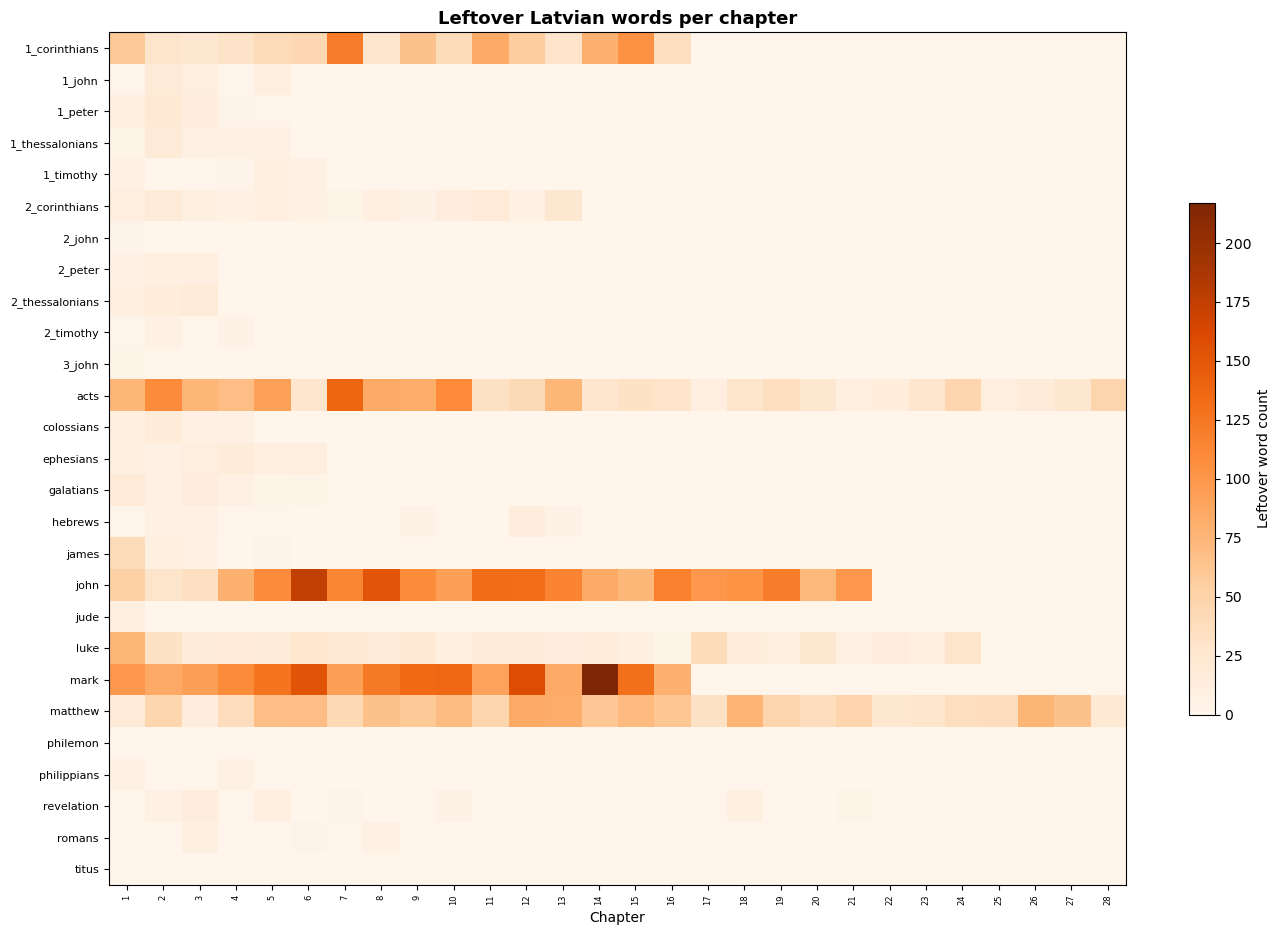

In [18]:
pivot = df.pivot_table(index='book', columns='chapter', values='leftover_latvian', fill_value=0)
pivot = pivot.reindex(sorted(pivot.index))  # alphabetical

fig, ax = plt.subplots(figsize=(max(14, pivot.shape[1] * 0.35), max(6, pivot.shape[0] * 0.35)))
im = ax.imshow(pivot.values, aspect='auto', cmap='Oranges', interpolation='nearest')
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, fontsize=6, rotation=90)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel('Chapter')
ax.set_title('Leftover Latvian words per chapter', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6, label='Leftover word count')
plt.tight_layout()
plt.savefig(f'{prefix_outputs}heatmap_latvian.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary table — books with most leftover issues

In [30]:
summary = book_df.sort_values('leftover_latvian', ascending=False)
summary['latvian_pct'] = summary['latvian_pct'].round(1)
summary = summary[['book','chapters','total_words','latvian_pct','leftover_latvian', 'latvian_maped_pct']]
summary.columns = ['Book','Chapters','Words','Latvian mapped %','Leftover Latvian', 'matched latvians']
book_df.to_csv(f'{prefix_outputs}bbl_mapings_coverage.csv')
print(summary.to_string(index=False))

           Book  Chapters  Words  Latvian mapped %  Leftover Latvian  matched latvians
           john        21  15727              82.3              2097         81.360407
           mark        16  11451              85.0              1914         81.140570
        matthew        28  18527              76.8              1435         76.482288
           acts        28  18584              71.8              1398         74.278712
  1_corinthians        16   6858              78.5               866         71.508306
           luke        24  19631              65.7               482         64.250510
  2_corinthians        13   4458              61.3               148         56.332508
      ephesians         6   2437              58.0                66         60.608658
     revelation        22   9892              74.3                62         83.965714
          james         5   1743              74.3                60         70.075758
      galatians         6   2236           

In [21]:
book_df.sort_values('leftover_latvian', ascending=False)[:5]

,book,total_words,latvian_mapped,leftover_latvian,chapters,latvian_pct
17,john,15727,12942,2097,21,82.291600
20,mark,11451,9732,1914,16,84.988211
21,matthew,18527,14228,1435,28,76.796027
11,acts,18584,13336,1398,28,71.760654
0,1_corinthians,6858,5381,866,16,78.463109
